In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 38.2 MB/s eta 0:00:00


In [4]:
torch.manual_seed(42)

## Moving to GPU

1. Check device
  `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`

2. Move the Model to GPU
  `model = model.to(device)`

3. Modify training loop by moving data to GPU
  `batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)`

4. Modify evaluation loop by moving data to GPU
  `test_features, test_labels = test_features.to(device), test_labels(device)`

5. Optimize GPU Usage
  a. Increase batch_size
  b. Enable DataLoader pinning
  `pin_memory=True`

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

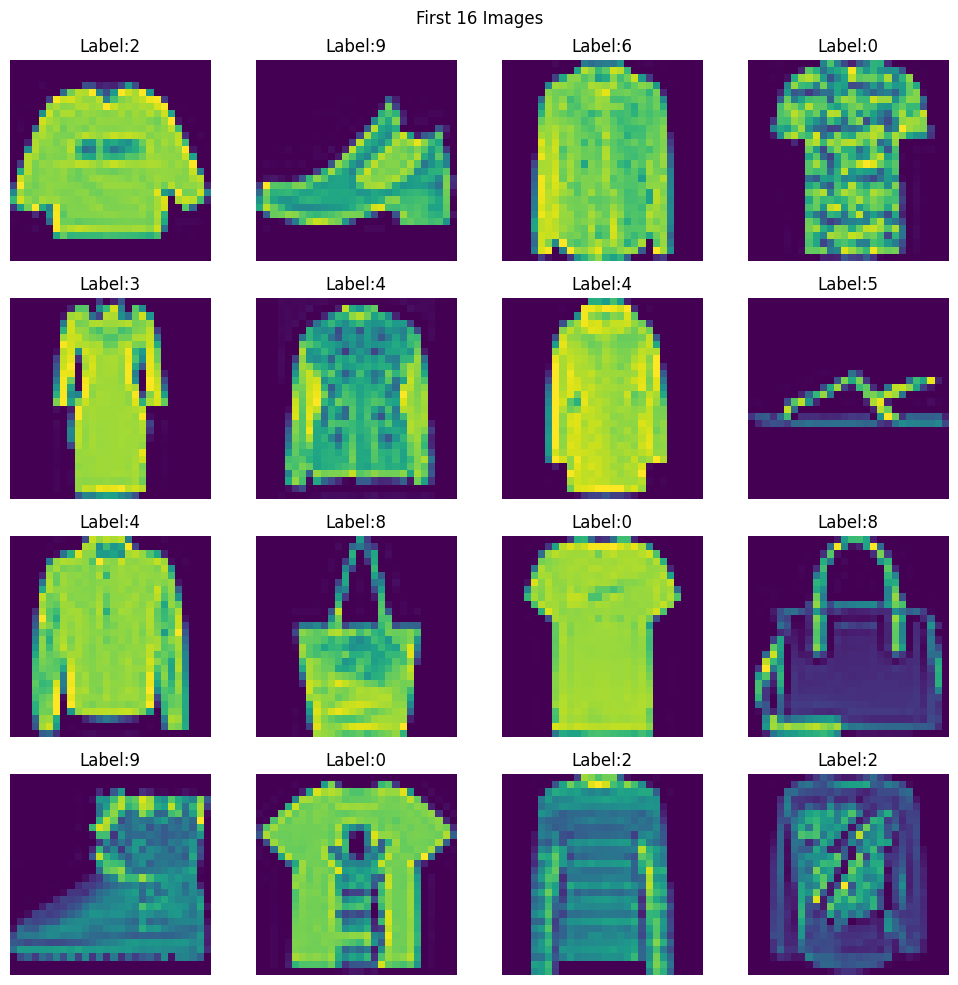

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle('First 16 Images')

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label:{df.iloc[i,0]}')

plt.tight_layout()
plt.show()

In [10]:
X = df.iloc[:, 1:].values
y = df.iloc[:,0].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [14]:
train_dataset = CustomDataset(X_train, y_train)

In [15]:
test_dataset = CustomDataset(X_test, y_test)

In [16]:
# class myNN(nn.Module):

#   def __init__(self, num_of_features):
#     super().__init__()
#     self.model = nn.Sequential(
#         nn.Linear(num_of_features, 128),
#         nn.BatchNorm1d(128),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),

#         nn.Linear(128, 64),
#         nn.BatchNorm1d(64),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),
#         nn.Linear(64, 10)
#     )

#   def forward(self, x):
#     return self.model(x)

In [17]:
class myNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neuron_per_layer, dropout_rate):
    super().__init__()

    layers = []
    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim, neuron_per_layer))
      layers.append(nn.BatchNorm1d(neuron_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neuron_per_layer

    layers.append(nn.Linear(input_dim, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)



In [18]:
def objective(trial):

  # next hyperparameter values from search space
  num_hidden_layers = trial.suggest_int('num_hidden_layers',1,5)
  neuron_per_layer = trial.suggest_int('neuron_per_layer', 8, 128, step=8)
  epochs = trial.suggest_int('epochs', 10, 50)
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
  batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
  optimizer = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)

  # dataloader init
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = myNN(input_dim, output_dim, num_hidden_layers, neuron_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()

  # optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
  if optimizer == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
  elif optimizer == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop
  for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_features, batch_labels in train_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      predictions = model(batch_features)

      loss = criterion(predictions, batch_labels)

      optimizer.zero_grad()

      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

      optimizer.step()

      epoch_loss += loss.item()
      if epoch % 5 == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss / len(train_loader):.4f}")

  # evaluation
  model.eval()

  total = 0
  correct = 0

  with torch.inference_mode():

    for test_features, test_labels in test_loader:

      test_features, test_labels = test_features.to(device), test_labels.to(device)
      outputs = model(test_features)

      _,prediction = torch.max(outputs, 1)

      total += test_labels.shape[0]
      correct += (prediction == test_labels).sum().item()

    accuracy = correct/total

  return accuracy


In [19]:
import optuna

In [20]:
study = optuna.create_study(direction='maximize')

[I 2026-06-20 15:19:57,100] A new study created in memory with name: no-name-8c948e6f-e1c8-44aa-9fe5-a44873a7676c


In [21]:
study.optimize(objective, n_trials=2)

Streaming output truncated to the last 5000 lines.
Epoch 0: loss = 1.2365
Epoch 0: loss = 1.2374
Epoch 0: loss = 1.2384
Epoch 0: loss = 1.2392
Epoch 0: loss = 1.2400
Epoch 0: loss = 1.2409
Epoch 0: loss = 1.2418
Epoch 0: loss = 1.2426
Epoch 0: loss = 1.2436
Epoch 0: loss = 1.2445
Epoch 0: loss = 1.2455
Epoch 0: loss = 1.2464
Epoch 0: loss = 1.2472
Epoch 0: loss = 1.2481
Epoch 0: loss = 1.2491
Epoch 0: loss = 1.2501
Epoch 0: loss = 1.2509
Epoch 0: loss = 1.2518
Epoch 0: loss = 1.2525
Epoch 0: loss = 1.2534
Epoch 0: loss = 1.2543
Epoch 0: loss = 1.2553
Epoch 0: loss = 1.2562
Epoch 0: loss = 1.2571
Epoch 0: loss = 1.2579
Epoch 0: loss = 1.2588
Epoch 0: loss = 1.2597
Epoch 0: loss = 1.2606
Epoch 0: loss = 1.2613
Epoch 0: loss = 1.2623
Epoch 0: loss = 1.2633
Epoch 0: loss = 1.2644
Epoch 0: loss = 1.2652
Epoch 0: loss = 1.2661
Epoch 0: loss = 1.2672
Epoch 0: loss = 1.2681
Epoch 0: loss = 1.2689
Epoch 0: loss = 1.2699
Epoch 0: loss = 1.2708
Epoch 0: loss = 1.2717
Epoch 0: loss = 1.2728
Epoch 

[I 2026-06-20 15:21:49,045] Trial 0 finished with value: 0.8494166666666667 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 128, 'epochs': 17, 'learning_rate': 0.004126217453482471, 'dropout_rate': 0.4626047436196823, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.006655812885318994}. Best is trial 0 with value: 0.8494166666666667.


Streaming output truncated to the last 5000 lines.
Epoch 5: loss = 0.7670
Epoch 5: loss = 0.7675
Epoch 5: loss = 0.7683
Epoch 5: loss = 0.7691
Epoch 5: loss = 0.7697
Epoch 5: loss = 0.7705
Epoch 5: loss = 0.7712
Epoch 5: loss = 0.7720
Epoch 5: loss = 0.7729
Epoch 5: loss = 0.7735
Epoch 5: loss = 0.7741
Epoch 5: loss = 0.7748
Epoch 5: loss = 0.7755
Epoch 5: loss = 0.7761
Epoch 5: loss = 0.7769
Epoch 5: loss = 0.7775
Epoch 5: loss = 0.7782
Epoch 5: loss = 0.7790
Epoch 5: loss = 0.7800
Epoch 5: loss = 0.7808
Epoch 5: loss = 0.7815
Epoch 5: loss = 0.7822
Epoch 5: loss = 0.7830
Epoch 5: loss = 0.7837
Epoch 5: loss = 0.7844
Epoch 5: loss = 0.7851
Epoch 5: loss = 0.7858
Epoch 5: loss = 0.7866
Epoch 5: loss = 0.7875
Epoch 5: loss = 0.7885
Epoch 5: loss = 0.7893
Epoch 5: loss = 0.7901
Epoch 5: loss = 0.7909
Epoch 5: loss = 0.7918
Epoch 5: loss = 0.7929
Epoch 5: loss = 0.7936
Epoch 5: loss = 0.7946
Epoch 5: loss = 0.7953
Epoch 5: loss = 0.7959
Epoch 5: loss = 0.7966
Epoch 5: loss = 0.7972
Epoch 

[I 2026-06-20 15:24:12,604] Trial 1 finished with value: 0.5144166666666666 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 56, 'epochs': 21, 'learning_rate': 0.008043218720243321, 'dropout_rate': 0.2132872150987232, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.004638901651059806}. Best is trial 0 with value: 0.8494166666666667.


In [22]:
study.best_params

{'num_hidden_layers': 5,
 'neuron_per_layer': 128,
 'epochs': 17,
 'learning_rate': 0.004126217453482471,
 'dropout_rate': 0.4626047436196823,
 'batch_size': 32,
 'optimizer': 'SGD',
 'weight_decay': 0.006655812885318994}

In [23]:
study.best_trial

FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.8494166666666667], datetime_start=datetime.datetime(2026, 6, 20, 15, 19, 57, 105920), datetime_complete=datetime.datetime(2026, 6, 20, 15, 21, 49, 45802), params={'num_hidden_layers': 5, 'neuron_per_layer': 128, 'epochs': 17, 'learning_rate': 0.004126217453482471, 'dropout_rate': 0.4626047436196823, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.006655812885318994}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_hidden_layers': IntDistribution(high=5, log=False, low=1, step=1), 'neuron_per_layer': IntDistribution(high=128, log=False, low=8, step=8), 'epochs': IntDistribution(high=50, log=False, low=10, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=1e-05, step=None), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'optimizer': CategoricalDistribution(choices=('Adam', 'SGD', 'R

In [24]:
study.best_value

0.8494166666666667